# Matrix Multiplication Code Challenges and Solutions to Practice Questions

## Code Challenge 1: SVD vs eigendecomposition for square symmetric matrices
- Create a square, symmetric matrix (5x5)
- Compute eig (save variables as W, L)
- Compute SVD (use variables U, S, V)
- Make images of all matrices
- Compare U and V
- Compare U and W


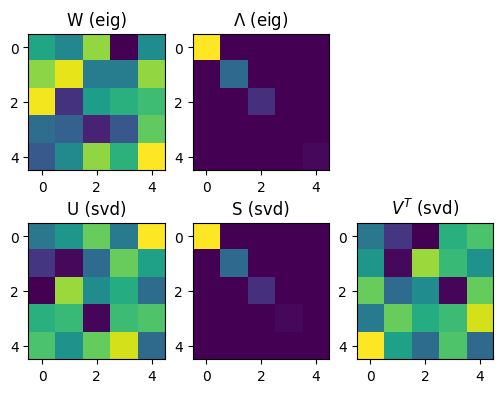

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix X (Square symmetric)
X = np.random.randn(5, 5)
X = X @ X.T

# Eig
L, W = np.linalg.eig(X)
# SVD
U, S, V_T = np.linalg.svd(X)

# Convert vectors to diagonal matrices
L = np.eye(5) * L
S = np.eye(5) * S

## Plot Images
# Define subplot layout
fig, axs = plt.subplot_mosaic(
    [
        ["A", "B", "."],
        ["C", "D", "E"],
    ],
    figsize=(6, 4.5),
)

# Add the images
imA = axs["A"].imshow(W)
imB = axs["B"].imshow(L)
imC = axs["C"].imshow(U)
imD = axs["D"].imshow(S)
imE = axs["E"].imshow(V_T)

# Titles
titles = ["W (eig)", r"$\Lambda$ (eig)", "U (svd)", "S (svd)", r"$V^T$ (svd)"]
for ax, title in zip(axs.values(), titles):
    ax.set_title(title)

plt.show()

In [70]:
# Compare U and V (they look like the transpose of each other to me)

print("U:\n", U)
print("V:\n", V_T.T)  # Numpy outputs V^T, so we need to transpose to get back to V

# Yep, definitely the transpose of U=V for a square symmetric matrix

U:
 [[-0.09432868  0.11348526  0.49080473 -0.07479701  0.85541763]
 [-0.47333466 -0.6892333  -0.17307939  0.48797119  0.18121647]
 [-0.72305504  0.61958039  0.04621903  0.25195289 -0.16641844]
 [ 0.28145468  0.34778831 -0.7034097   0.35882873  0.41986103]
 [ 0.40624017  0.08509986  0.48190542  0.75103343 -0.17732143]]
V:
 [[-0.09432868  0.11348526  0.49080473 -0.07479701  0.85541763]
 [-0.47333466 -0.6892333  -0.17307939  0.48797119  0.18121647]
 [-0.72305504  0.61958039  0.04621903  0.25195289 -0.16641844]
 [ 0.28145468  0.34778831 -0.7034097   0.35882873  0.41986103]
 [ 0.40624017  0.08509986  0.48190542  0.75103343 -0.17732143]]


In [71]:
# Compare U and W

print("U:\n", U)
print("W:\n", W)

# Okay these are the same. U is not always ordered (because eig function not svd). Also, sign ambiguity but that's standard.

U:
 [[-0.09432868  0.11348526  0.49080473 -0.07479701  0.85541763]
 [-0.47333466 -0.6892333  -0.17307939  0.48797119  0.18121647]
 [-0.72305504  0.61958039  0.04621903  0.25195289 -0.16641844]
 [ 0.28145468  0.34778831 -0.7034097   0.35882873  0.41986103]
 [ 0.40624017  0.08509986  0.48190542  0.75103343 -0.17732143]]
W:
 [[ 0.09432868 -0.11348526  0.49080473 -0.85541763 -0.07479701]
 [ 0.47333466  0.6892333  -0.17307939 -0.18121647  0.48797119]
 [ 0.72305504 -0.61958039  0.04621903  0.16641844  0.25195289]
 [-0.28145468 -0.34778831 -0.7034097  -0.41986103  0.35882873]
 [-0.40624017 -0.08509986  0.48190542  0.17732143  0.75103343]]


## Code Challenge 2: U from eigendecomposition of $A^TA$
- Create a matrix A (3x6)
- Perform full svd on A (variable names U_svd, S_svd, V_T_svd)
- Compute eigendecomp of $A^TA$ (variable names V, L($\Lambda$))
- Confirm that V == V_svd
- Check relationship between S_svd and L
- Create matrix U using A, V, and L
- Confirm that U == U_svd


In [ ]:
# Matrix A
A = np.random.rand(3, 6)

# SVD
U_svd, S_svd, V_T_svd = np.linalg.svd(A)

# Eig
L, V = np.linalg.eig(A.T @ A)

print("V (svd):\n", V_T_svd.T)
print("V (eig):\n", V)

# sort eigenvalues and eigenvectors
idx = np.argsort(L)[::-1]
L = L[idx]
V = V[:, idx]

# Compute U from V and L
U = np.empty((3, 3))
for i in range(3):
    sigma = np.sqrt(L[i])
    U[:, i] = A @ V[:, i] / sigma

print("U (svd):\n", U_svd)
print("U (eig):\n", U)

V (svd):
 [[-0.34512017  0.49712678 -0.23715195 -0.64229727 -0.40006429  0.07013399]
 [-0.21274075  0.15792711 -0.34938697  0.63110431 -0.4970031  -0.40301913]
 [-0.51174463 -0.54566728  0.42692863 -0.22189356 -0.20502549 -0.40844142]
 [-0.48271768  0.38302197  0.54366855  0.36555359  0.0591282   0.43310132]
 [-0.51155637  0.07320925 -0.39828724  0.00435555  0.71984856 -0.23688994]
 [-0.28114872 -0.52735736 -0.43036198  0.07922387 -0.17094719  0.64972211]]
V (eig):
 [[-0.34512017+0.j         -0.49712678+0.j         -0.23715195+0.j
  -0.18051909+0.31363766j -0.18051909-0.31363766j -0.11730523+0.j        ]
 [-0.21274075+0.j         -0.15792711+0.j         -0.34938697+0.j
   0.73515649+0.j          0.73515649-0.j          0.15189225+0.j        ]
 [-0.51174463+0.j          0.54566728+0.j          0.42692863+0.j
   0.25899984+0.17966488j  0.25899984-0.17966488j -0.36579071+0.j        ]
 [-0.48271768+0.j         -0.38302197+0.j          0.54366855+0.j
  -0.15937396-0.18353445j -0.15937396+0.

/var/folders/6x/_9kyqs096vv_xhnb0sfv30z80000gn/T/ipykernel_53322/231141854.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  U[:, i] = A @ V[:, i] / sigma
